In [ ]:
!pip install transformers
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 27.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 43.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.3/519.3 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset,DatasetDict
from transformers import AutoTokenizer,TFAutoModelForSequenceClassification
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Experiments for research paper/Cyberbullying detection/train_merged.csv"
tweets_df = pd.read_csv(DATA_PATH)
tweets_df.head(10)

,Insult,Date,Comment
0,1,20120618192155Z,"""You fuck your dad."""
1,0,20120528192215Z,"""i really don't understand your point.\xa0 It ..."
2,0,NaN,"""A\\xc2\\xa0majority of Canadians can and has ..."
3,0,NaN,"""listen if you dont wanna get married to a man..."
4,0,20120619094753Z,"""C\xe1c b\u1ea1n xu\u1ed1ng \u0111\u01b0\u1edd..."
5,0,20120620171226Z,"""@SDL OK, but I would hope they'd sign him to ..."
6,0,20120503012628Z,"""Yeah and where are you now?"""
7,1,NaN,"""shut the fuck up. you and the rest of your fa..."
8,1,20120502173553Z,"""Either you are fake or extremely stupid...may..."
9,1,20120620160512Z,"""That you are an idiot who understands neither..."


In [ ]:
!pip install contractions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 kB 11.3 MB/s eta 0:00:00


In [ ]:
import re

# Remove escape characters
tweets_df['Comment_cleaned'] = tweets_df['Comment'].apply(lambda x: re.sub(r'\\[a-zA-Z]', ' ', x))

#Remove numbers
tweets_df['Comment_cleaned'] = tweets_df['Comment_cleaned'].apply(lambda x: re.sub(r'\d+', ' ', x))

# Remove URLs and mentions (@username) from the tweets
tweets_df['Comment_cleaned'] = tweets_df['Comment_cleaned'].apply(lambda x: re.sub(r'http\S+', ' ', x)) # Remove URLs
tweets_df['Comment_cleaned'] = tweets_df['Comment_cleaned'].apply(lambda x: re.sub(r'@\w+', ' ', x)) # Remove mentions


import contractions

def expand_contractions(text):
    expanded_text = contractions.fix(text)
    return expanded_text

tweets_df['Comment_cleaned'] = tweets_df['Comment_cleaned'].apply(expand_contractions)


# Remove punctuation and convert all characters to lowercase
tweets_df['Comment_cleaned'] = tweets_df['Comment_cleaned'].apply(lambda x: re.sub(r'[^\w\s]', ' ', x)) # Remove punctuation
tweets_df['Comment_cleaned'] = tweets_df['Comment_cleaned'].apply(lambda x: x.lower()) # Convert to lowercase



# Remove stop words
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = stopwords.words('english')
# tweets_df['Comment_cleaned'] = tweets_df['Comment_cleaned'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

#Remove single alphabet
tweets_df['Comment_cleaned'] = tweets_df['Comment_cleaned'].apply(lambda x: re.sub(r'\b\w\b', '', x))

tweets_df.head(10)

,Insult,Date,Comment,Comment_cleaned
0,1,20120618192155Z,"""You fuck your dad.""",you fuck your dad
1,0,20120528192215Z,"""i really don't understand your point.\xa0 It ...",really do not understand your point it se...
2,0,NaN,"""A\\xc2\\xa0majority of Canadians can and has ...",majority of canadians can and has been ...
3,0,NaN,"""listen if you dont wanna get married to a man...",listen if you do not want to get married to ...
4,0,20120619094753Z,"""C\xe1c b\u1ea1n xu\u1ed1ng \u0111\u01b0\u1edd...",ea xu ed ng eddng bi ec you e...
5,0,20120620171226Z,"""@SDL OK, but I would hope they'd sign him to ...",ok but would hope they would sign him to ...
6,0,20120503012628Z,"""Yeah and where are you now?""",yeah and where are you now
7,1,NaN,"""shut the fuck up. you and the rest of your fa...",shut the fuck up you and the rest of your fa...
8,1,20120502173553Z,"""Either you are fake or extremely stupid...may...",either you are fake or extremely stupid may...
9,1,20120620160512Z,"""That you are an idiot who understands neither...",that you are an idiot who understands neither...


In [ ]:
tweets_df.head()

,Insult,Date,Comment,Comment_cleaned
0,1,20120618192155Z,"""You fuck your dad.""",you fuck your dad
1,0,20120528192215Z,"""i really don't understand your point.\xa0 It ...",really do not understand your point it se...
2,0,NaN,"""A\\xc2\\xa0majority of Canadians can and has ...",majority of canadians can and has been ...
3,0,NaN,"""listen if you dont wanna get married to a man...",listen if you do not want to get married to ...
4,0,20120619094753Z,"""C\xe1c b\u1ea1n xu\u1ed1ng \u0111\u01b0\u1edd...",ea xu ed ng eddng bi ec you e...


In [ ]:
tweets_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Experiments for research paper/Cyberbullying detection/train_merged_cleaned.csv")

In [ ]:
from datasets import Dataset



ds = Dataset.from_pandas(tweets_df)
ds



Dataset({
    features: ['Insult', 'Date', 'Comment', 'Comment_cleaned'],
    num_rows: 6594
})

In [ ]:
DATACLEAN_PATH = "/content/drive/MyDrive/Colab Notebooks/Experiments for research paper/Cyberbullying detection/train_merged_cleaned.csv"

In [ ]:
dataset = load_dataset('csv', data_files=DATACLEAN_PATH, split='train')

dataset

Extracting data files:   0%|          | 0/1 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['Unnamed: 0', 'Insult', 'Date', 'Comment', 'Comment_cleaned'],
    num_rows: 6594
})

In [ ]:
train_test_valid = ds.train_test_split(test_size=.40)

test_valid = train_test_valid['test'].train_test_split(test_size=0.5)

train_test_valid_dataset = DatasetDict({
    'train': train_test_valid['train'],
    'test': test_valid['test'],
    'valid': test_valid['train']
    })


dataset = train_test_valid_dataset.remove_columns(['Date', 'Comment'])
dataset

DatasetDict({
    train: Dataset({
        features: ['Insult', 'Comment_cleaned'],
        num_rows: 3956
    })
    test: Dataset({
        features: ['Insult', 'Comment_cleaned'],
        num_rows: 1319
    })
    valid: Dataset({
        features: ['Insult', 'Comment_cleaned'],
        num_rows: 1319
    })
})

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("GroNLP/hateBERT")

In [ ]:
text = "Just checking tokenization"

output = tokenizer(text)

output


{'input_ids': [101, 2074, 9361, 19204, 3989, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(output['input_ids'])
tokens

['[CLS]', 'just', 'checking', 'token', '##ization', '[SEP]']

In [ ]:
print(f"Tokenized text: {tokenizer.convert_tokens_to_string(tokens)}")

Tokenized text: [CLS] just checking tokenization [SEP]


In [ ]:
print(f"Vocab size is : {tokenizer.vocab_size}")

print(f"Model max length is : {tokenizer.model_max_length}")

print(f"Model input names are: {tokenizer.model_input_names}")

Vocab size is : 30522
Model max length is : 512
Model input names are: ['input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
ds

Dataset({
    features: ['Insult', 'Date', 'Comment', 'Comment_cleaned'],
    num_rows: 6594
})

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Insult', 'Comment_cleaned'],
        num_rows: 3956
    })
    test: Dataset({
        features: ['Insult', 'Comment_cleaned'],
        num_rows: 1319
    })
    valid: Dataset({
        features: ['Insult', 'Comment_cleaned'],
        num_rows: 1319
    })
})

In [ ]:
def tokenize_function(train_dataset):
    return tokenizer(train_dataset['Comment_cleaned'], padding='max_length', truncation=True)


tokenized_dataset = dataset.map(tokenize_function, batched=True)

tokenized_dataset

train_dataset = tokenized_dataset['train']
eval_dataset = tokenized_dataset['valid']
test_dataset = tokenized_dataset['test']

Map:   0%|          | 0/3956 [00:00<?, ? examples/s]

Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['Insult', 'Comment_cleaned', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3956
})

In [ ]:
test_dataset

Dataset({
    features: ['Insult', 'Comment_cleaned', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1319
})

In [ ]:
eval_dataset

Dataset({
    features: ['Insult', 'Comment_cleaned', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1319
})

In [ ]:
train_set = train_dataset.remove_columns([ "Comment_cleaned"]).with_format('tensorflow')

tf_eval_dataset = eval_dataset.remove_columns(["Comment_cleaned"]).with_format('tensorflow')

tf_test_dataset = test_dataset.remove_columns([ "Comment_cleaned"]).with_format('tensorflow')

In [ ]:
train_features = { x: train_set[x] for x in tokenizer.model_input_names  }

train_set_for_final_model = tf.data.Dataset.from_tensor_slices((train_features, train_set['Insult'] ))

train_set_for_final_model = train_set_for_final_model.shuffle(len(train_set)).batch(8)


eval_features = {x: tf_eval_dataset[x] for x in tokenizer.model_input_names}
val_set_for_final_model = tf.data.Dataset.from_tensor_slices((eval_features, tf_eval_dataset["Insult"]))
val_set_for_final_model = val_set_for_final_model.batch(8)

test_features = {x: tf_test_dataset[x] for x in tokenizer.model_input_names}
test_set_for_final_model = tf.data.Dataset.from_tensor_slices((test_features, tf_test_dataset["Insult"]))
test_set_for_final_model =test_set_for_final_model.batch(8)

In [ ]:
model = TFAutoModelForSequenceClassification.from_pretrained("GroNLP/hateBERT", num_labels=2)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=tf.metrics.SparseCategoricalAccuracy(),
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
history = model.fit(train_set_for_final_model, validation_data=val_set_for_final_model, epochs=10)

Epoch 1/10
495/495 [==============================] - 605s 1s/step - loss: 0.3171 - sparse_categorical_accuracy: 0.8693 - val_loss: 0.2620 - val_sparse_categorical_accuracy: 0.8969
Epoch 2/10
495/495 [==============================] - 538s 1s/step - loss: 0.1403 - sparse_categorical_accuracy: 0.9489 - val_loss: 0.3372 - val_sparse_categorical_accuracy: 0.8863
Epoch 3/10
495/495 [==============================] - 539s 1s/step - loss: 0.0678 - sparse_categorical_accuracy: 0.9772 - val_loss: 0.3930 - val_sparse_categorical_accuracy: 0.8855
Epoch 4/10
495/495 [==============================] - 511s 1s/step - loss: 0.0465 - sparse_categorical_accuracy: 0.9841 - val_loss: 0.5481 - val_sparse_categorical_accuracy: 0.8817
Epoch 5/10
495/495 [==============================] - 511s 1s/step - loss: 0.0302 - sparse_categorical_accuracy: 0.9904 - val_loss: 0.4880 - val_sparse_categorical_accuracy: 0.8582
Epoch 6/10
495/495 [==============================] - 511s 1s/step - loss: 0.0207 - sparse_cate

In [ ]:
test_loss, test_acc = model.evaluate(test_set_for_final_model,verbose=2)
print('\nTest accuracy:', test_acc)

165/165 - 55s - loss: 0.7467 - sparse_categorical_accuracy: 0.8590 - 55s/epoch - 336ms/step

Test accuracy: 0.8589840531349182


In [ ]:
from sklearn.metrics import classification_report

# Make predictions using the model on the test set
predictions = model.predict(test_set_for_final_model)
predicted_classes = np.argmax(predictions.logits, axis=1)

# Get the true classes from the test dataset
true_classes = tf_test_dataset["Insult"].numpy()

# Compute the classification report
class_labels = ["Neutral", "Insulting"]
classification_rep = classification_report(true_classes, predicted_classes, target_names=class_labels)

print("Classification Report:")
print(classification_rep)


165/165 [==============================] - 58s 333ms/step
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.91      0.90      0.90       956
   Insulting       0.74      0.75      0.75       363

    accuracy                           0.86      1319
   macro avg       0.82      0.83      0.82      1319
weighted avg       0.86      0.86      0.86      1319



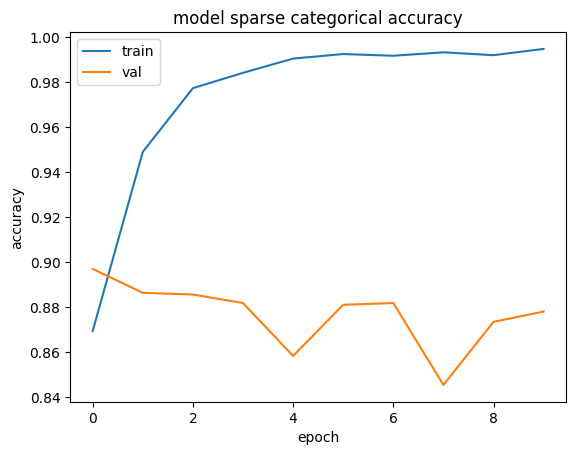

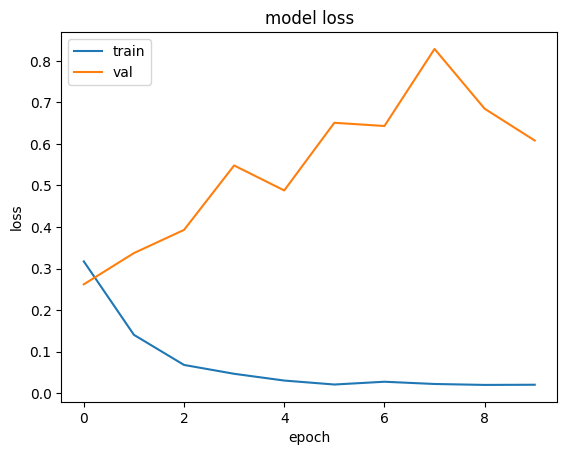

In [ ]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model sparse categorical accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


In [ ]:
predict_score_and_class_dict = {0: 'Neutral',
 1: 'Insulting'}
preds = model(tokenizer(["you can do it", "Stupid"],return_tensors="tf",padding=True,truncation=True))['logits']

print(preds)

class_preds = np.argmax(preds, axis=1)

for pred in class_preds:
  print(predict_score_and_class_dict[pred])

tf.Tensor(
[[ 4.7105794 -3.8345187]
 [-1.5932958  1.0721487]], shape=(2, 2), dtype=float32)
Neutral
Insulting


In [ ]:
from sklearn.metrics import confusion_matrix

# Predict classes for the test dataset
predictions = model.predict(test_set_for_final_model)
predicted_classes = np.argmax(predictions.logits, axis=1)

# Get the true classes from the test dataset
true_classes = tf_test_dataset["Insult"].numpy()

# Compute the confusion matrix
confusion_mat = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(confusion_mat)


165/165 [==============================] - 55s 333ms/step
Confusion Matrix:
[[859  97]
 [ 89 274]]


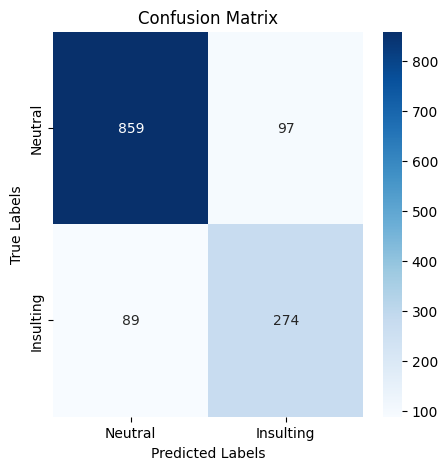

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
# confusion_mat = confusion_matrix(true_classes, predicted_classes)

# Define class labels
class_labels = ["Neutral", "Insulting"]

# Create a heatmap of the confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
